In [11]:
import os
import sys
import json
import warnings
import numpy as np
import sympy as sp
import pandas as pd
import proplot as pplt
from IPython.display import display,HTML
sys.path.insert(0,'..')
warnings.filterwarnings('ignore')
pplt.rc.update({
    'tick.minor':False,
    'savefig.dpi':300,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'legend.fontsize':9})

In [12]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
MODELSDIR = CONFIGS['filepaths']['models']
SRCONFIG  = CONFIGS['experiments']['sr']
SEEDS     = SRCONFIG['seeds']

In [13]:
VARDICT = {
    'rh':r'\widehat{\mathrm{RH}}',
    'thetae':r'\widehat{\theta}_{e}',
    'thetaestar':r'{\widehat{\theta}_{e}^{*}}',
    'lf':r'\mathrm{LF}',
    'shf':r'\mathrm{SHF}',
    'lhf':r'\mathrm{LHF}',}

SYMBOLS  = {k:sp.Symbol(k) for k in VARDICT}

FUNCDICT = {
    'cube':lambda x:x**3,
    'square':lambda x:x**2,
    'sqrt':sp.sqrt,
    'abs':sp.Abs,
    'neg':lambda x:-x,
    'exp':sp.exp,
    'log':sp.log,
    'sin':sp.sin,
    'cos':sp.cos}

LATEXREPLACE = {
    SYMBOLS['rh']:sp.Symbol(r'\widehat{\mathrm{RH}}'),
    SYMBOLS['thetae']:sp.Symbol(r'\widehat{\theta_e}'),
    SYMBOLS['thetaestar']:sp.Symbol(r'\widehat{\theta_e^*}'),
    SYMBOLS['lf']:sp.Symbol(r'\mathrm{LF}'),
    SYMBOLS['shf']:sp.Symbol(r'\mathrm{SHF}'),
    SYMBOLS['lhf']:sp.Symbol(r'\mathrm{LHF}')}

TERMORDER = {
    'rh':0,
    'thetae':1,
    'thetaestar':2,
    'lf':3,
    'shf':4,
    'lhf':5}

def _to_sympy_expr(eq):
    return sp.sympify(eq,locals={**SYMBOLS,**FUNCDICT})

def _round_numbers(expr,ndigits=4):
    return expr.xreplace({n: sp.Float(round(float(n),ndigits),ndigits) for n in expr.atoms(sp.Float)})

def _term_key(term):
    symbols = term.free_symbols
    if not symbols:
        return (99, str(term))
    names = sorted(s.name for s in symbols)
    return (min(TERMORDER.get(n,50) for n in names),str(term))

def _ordered_add_terms(expr):
    if isinstance(expr,sp.Add):
        terms = sp.Add.make_args(expr)
        return sp.Add(*sorted(terms,key=_term_key),evaluate=False)
    return expr

def _order_expr(expr):
    if expr.args:
        expr = expr.func(*[_order_expr(arg) for arg in expr.args],evaluate=False)
    if isinstance(expr,sp.Add):
        expr = _ordered_add_terms(expr)
    return expr

def _latex_expr(expr):
    SYMBOLNAMES = {SYMBOLS[k]: v for k, v in VARDICT.items()}
    latex = sp.latex(expr,symbol_names=SYMBOLNAMES,mul_symbol='dot')
    latex = latex.replace(r'\left', '').replace(r'\right', '')
    latex = ' '.join(latex.split())
    varslatex = list(VARDICT.values())
    for a in varslatex:
        for b in varslatex:
            latex = latex.replace(f'{a} \\cdot {b}',f'{a}({b})')
    return latex

def prettify(eq):
    try:
        expr = _to_sympy_expr(str(eq).strip())
        expr = sp.expand(expr)
        expr = sp.simplify(expr)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return '$'+_latex_expr(expr)+'$'
    except Exception:
        return str(eq).strip()
        
def load_equations(runname):
    seedframes = {}
    for seed in SEEDS:
        filepath = os.path.join(MODELSDIR, 'sr', f'{runname}_{seed}_equations.csv')
        df = pd.read_csv(filepath)
        df['seed'] = seed
        seedframes[seed] = df
    return seedframes
    
def equation_table(runname):
    seedframes = load_equations(runname)
    if not seedframes:
        return pd.DataFrame()
    rows = []
    for seed,df in seedframes.items():
        for _,row in df.iterrows():
            rows.append({'Seed':seed,'Complexity':int(row['complexity']),
                         'Loss':float(row['loss']),'Equation':prettify(str(row['equation']))})
    return pd.DataFrame(rows).sort_values(['Seed','Complexity']).reset_index(drop=True)

In [14]:
for runname in SRCONFIG['runs']:
    tbl = equation_table(runname)
    display(HTML(tbl.to_html(escape=False,index=False)))

Seed,Complexity,Loss,Equation
42,1,0.998213,$0.0017$
42,2,0.679273,$\widehat{\mathrm{RH}}$
42,4,0.650225,$\widehat{\mathrm{RH}}^{3}$
42,6,0.631149,$1.339 \cdot \widehat{\mathrm{RH}}^{3}$
42,8,0.622777,$\widehat{\mathrm{RH}}^{3} + 0.4826 \cdot \widehat{\mathrm{RH}}^{2} + 0.0776 \cdot \widehat{\mathrm{RH}} - 0.183$
42,9,0.603885,$\widehat{\mathrm{RH}} - |{\mathrm{SHF} + 0.4472}| + 0.6026$
42,10,0.579758,$\widehat{\mathrm{RH}} + \widehat{\theta}_{e} - {\widehat{\theta}_{e}^{*}} - 1.086$
42,11,0.500468,$4.3 \cdot \widehat{\theta}_{e} - 6.177 \cdot {\widehat{\theta}_{e}^{*}} - 4.714$
42,13,0.493033,$- \mathrm{LF}(\widehat{\theta}_{e}) + 1.415 \cdot \mathrm{LF}({\widehat{\theta}_{e}^{*}}) + 1.091 \cdot \mathrm{LF} + 4.761 \cdot \widehat{\theta}_{e} - 6.734 \cdot {\widehat{\theta}_{e}^{*}} - 5.195$
42,14,0.484834,$\widehat{\mathrm{RH}}(\widehat{\theta}_{e}) - 1.436 \cdot \widehat{\mathrm{RH}}({\widehat{\theta}_{e}^{*}}) - 1.081 \cdot \widehat{\mathrm{RH}} + 3.383 \cdot \widehat{\theta}_{e} - 4.857 \cdot {\widehat{\theta}_{e}^{*}} - 3.657$


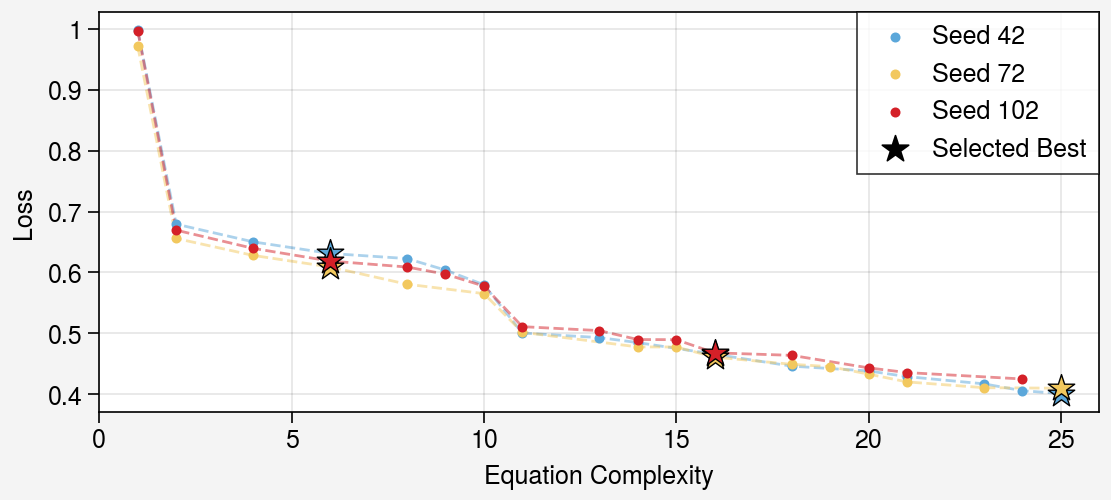

In [15]:
COLORS = ['#5BA7DA','#F2C85E','#D42028']
BEST   = {
    42:[6,16,25],
    72:[6,16,25],
    102:[6,16]}

for runname in CONFIGS['experiments']['sr']['runs']:
    seedframes = load_equations(runname)
    fig,ax = pplt.subplots(refwidth=5,refheight=2)
    ax.format(xlabel='Equation Complexity',xlim=(0,26),ylabel='Loss')
    for i,(seed,df) in enumerate(sorted(seedframes.items())):
        df      = df.sort_values('complexity')
        color   = COLORS[i%len(COLORS)]
        ax.plot(df['complexity'],df['loss'],color=color,alpha=0.5,linewidth=1,linestyle='--',zorder=1,label='')
        ax.scatter(df['complexity'],df['loss'],color=color,marker='.',zorder=3,label=f'Seed {seed}')
        bestcs = BEST.get(seed)
        if bestcs is not None:
            if not isinstance(bestcs,(list,tuple,set)):
                bestcs = [bestcs]
            for bestc in bestcs:
                row = df[df['complexity']==bestc]
                if not row.empty:
                    ax.scatter([row['complexity'].values[0]],[row['loss'].values[0]],
                        color=color,edgecolors='k',marker='*',markersize=100,linewidths=0.5,zorder=5)  
    ax.scatter([],[],color='k',marker='*',markersize=100,label='Selected Best')
    ax.legend(loc='ur',ncols=1)
    pplt.show()
    fig.save('../figs/fig_S2.jpg')

In [16]:
def expand_equation(eq_str,var_names):
    syms  = {v: sp.Symbol(v) for v in var_names}
    ns_sp = {'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
             'sqrt':sp.sqrt,'exp':sp.exp,'log':sp.log,'abs':sp.Abs,
             'sin':sp.sin,'cos':sp.cos,'__builtins__':{},'pi':sp.pi,**syms}
    expr_exp = sp.expand(eval(eq_str, ns_sp))

    rh_s, te_s, tes_s, shf_s = [sp.Symbol(v) for v in ['rh','thetae','thetaestar','shf']]
    c_cube  = float(expr_exp.coeff(rh_s,  3))
    c_te    = float(expr_exp.coeff(te_s,  1))
    c_tes   = float(expr_exp.coeff(tes_s, 1))
    c_shf   = float(expr_exp.coeff(shf_s, 1))   # linear shf only, not inside abs
    c_const = float(expr_exp.subs([(sp.Symbol(v), 0) for v in var_names]))

    # abs(shf-lf) coefficient via finite difference:
    # fix lf=1, increase shf from 2→3: abs increases by exactly 1 regardless of
    # any small additive constant inside abs (since d|shf-lf|/d(shf) = sign(shf-lf) = 1)
    ns_num = {'cube':lambda x:x**3,'square':lambda x:x**2,'neg':lambda x:-x,
              'sqrt':np.sqrt,'exp':np.exp,'log':np.log,'abs':np.abs,
              'sin':np.sin,'cos':np.cos,'__builtins__':{},'pi':float(np.pi)}
    def ev_num(**kw):
        return float(eval(eq_str, {**ns_num, **{v:0.0 for v in var_names}, **kw}))
    def resid(shf_v, lf_v):
        return ev_num(shf=shf_v, lf=lf_v) - c_shf*shf_v - c_const
    c_abs = resid(3.0, 1.0) - resid(2.0, 1.0)

    return {'cube(rh)':round(c_cube,4),'thetae':round(c_te,4),'thetaestar':round(c_tes,4),
            'shf':round(c_shf,4),'abs(shf-lf)':round(c_abs,4),'const':round(c_const,4)}

def coefficient_table(eqname, eqspec):
    runname   = eqspec['runfrom']
    runconfig = SRCONFIG['runs'][runname]
    var_names = runconfig['fieldvars'] + runconfig.get('localvars',[])
    refcx     = eqspec['refcomplexity']
    rows = []
    for seed in SRCONFIG['seeds']:
        csvpath = os.path.join(MODELSDIR,'sr',f'{runname}_{seed}_equations.csv')
        if not os.path.exists(csvpath):
            continue
        df  = pd.read_csv(csvpath)
        row = df[df['complexity'] == refcx]
        if row.empty:
            print(f'  Seed {seed}: no equation at complexity {refcx} (max={df.complexity.max()}), skipping')
            continue
        coeffs = expand_equation(row.iloc[0]['equation'], var_names)
        rows.append({'seed':seed, 'loss':round(row.iloc[0]['loss'],6), **coeffs,
                     'equation':row.iloc[0]['equation']})
    if not rows:
        return None
    df_out   = pd.DataFrame(rows).set_index('seed')
    num_cols = ['cube(rh)','thetae','thetaestar','shf','abs(shf-lf)','const']
    avg_row  = df_out[num_cols].mean().round(4)
    avg_row.name = 'average'
    return pd.concat([df_out, avg_row.to_frame().T])

print('Coefficient tables for optimized SR equations at refcomplexity:\n')
for eqname, eqspec in SRCONFIG.get('optimizedeqs', {}).items():
    print(f'=== {eqname}  (complexity {eqspec["refcomplexity"]}) ===')
    tbl = coefficient_table(eqname, eqspec)
    if tbl is not None:
        display(tbl[['loss','cube(rh)','thetae','thetaestar','shf','abs(shf-lf)','const','equation']])
    print()

Coefficient tables for optimized SR equations at refcomplexity:

=== sr_lo  (complexity 6) ===


,loss,cube(rh),thetae,thetaestar,shf,abs(shf-lf),const,equation
42,0.631149,1.3393,0.0,0.0,0.0,0.0,0.0,cube(rh) * 1.3392863
72,0.608985,1.3439,0.0,0.0,0.0,0.0,0.0,cube(rh) * 1.3439076
102,0.618688,1.3518,0.0,0.0,0.0,0.0,0.0,cube(rh * 1.1057115)
average,NaN,1.3450,0.0,0.0,0.0,0.0,0.0,NaN



=== sr_med  (complexity 16) ===


,loss,cube(rh),thetae,thetaestar,shf,abs(shf-lf),const,equation
42,0.465695,1.0,2.6511,-3.8722,0.0,0.0,-3.0062,(((thetae * 2.6511006) + -3.0061975) + cube(rh...
72,0.460944,1.0,2.5937,-3.7788,0.0,0.0,-2.9235,((thetaestar - (thetae * 0.6863855)) * -3.7788...
102,0.468011,1.0,2.5364,-3.7382,0.0,0.0,-2.8563,((thetaestar - (thetae * 0.67849964)) * -3.738...
average,NaN,1.0,2.5937,-3.7964,0.0,0.0,-2.9287,NaN



=== sr_hi  (complexity 25) ===
  Seed 102: no equation at complexity 25 (max=24), skipping


,loss,cube(rh),thetae,thetaestar,shf,abs(shf-lf),const,equation
42,0.401158,1.0,2.3514,-3.0594,-1.0000,-1.0,-2.2563,(thetaestar * -3.059437) + ((thetae * 2.351385...
72,0.409891,1.0,2.8617,-3.5476,-1.1116,-1.0,-2.6661,(cube(rh) - ((shf * 1.1116208) + abs(shf - lf)...
average,NaN,1.0,2.6066,-3.3035,-1.0558,-1.0,-2.4612,NaN


In [17]:
from IPython.display import Latex

def load_optimized(name):
    import pickle
    pklpath = os.path.join(MODELSDIR,'sr','optimized_equations.pkl')
    if not os.path.exists(pklpath):
        return None
    with open(pklpath,'rb') as f:
        registry = pickle.load(f)
    return registry.get(name)

def prettify_optimized(opt):
    '''Substitute optimized numeric constants into the form string and prettify.'''
    form      = opt['form']
    constants = opt['constants']
    # Replace constant names with their numeric values so sympy sees a pure expression
    ns = {**SYMBOLS, **FUNCDICT}
    ns.update({k: sp.Float(v) for k,v in constants.items()})
    try:
        expr = eval(form, {'__builtins__': {}}, ns)
        expr = sp.expand(expr)
        expr = _round_numbers(expr, ndigits=4)
        expr = _order_expr(expr)
        return '$\\hat{P} = ' + _latex_expr(expr) + '$'
    except Exception as e:
        return f'{form}  [render error: {e}]'

rows = []
for name in SRCONFIG.get('optimizedeqs', {}):
    opt = load_optimized(name)
    if opt is None:
        print(f'{name}: not yet optimized')
        continue
    rows.append({
        'Name':      name,
        'Equation':  prettify_optimized(opt),
        'Train MSE': f"{opt['train_loss']:.4f}",
        'Valid MSE': f"{opt['valid_loss']:.4f}",
    })

display(HTML(pd.DataFrame(rows).to_html(escape=False,index=False)))

sr_lo: not yet optimized
sr_hi: not yet optimized


Name,Equation,Train MSE,Valid MSE
sr_med,$\hat{P} = 1.0 \cdot \widehat{\mathrm{RH}}^{3} + 2.594 \cdot \widehat{\theta}_{e} - 3.796 \cdot {\widehat{\theta}_{e}^{*}} - 2.929$,0.4676,0.4791
